# Comparison Metrics for Different SNID Analyses

This notebook compares the performance of SNID across different datasets: CfA, CSP, Modjaz (Fixed Type), Modjaz (Fixed Subtype), and ZTF.

Metrics calculated in 5-day bins of true age (Limited to -15 to 25 days):
- Bias (Mean Residual)
- Spread (Standard Deviation of Residuals)
- RMSE
- Count

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use('/Users/pxm588@student.bham.ac.uk/PhD/cfa_spectra_pipeline/src/GausSN.mplstyle')

# Define paths to the datasets
datasets = {
    'CfA': {
        'path': '../../output/cfa_spectra_analysis/cfa_found_dataset.csv',
        't_true': 'phase',
        't_snid': 'SNID_age',
        't_err': 'SNID_err',
        'subtype': 'Wang_class'
    },
    'CSP': {
        'path': '../../output/csp_spectra_analysis/csp_found_dataset.csv',
        't_true': 'phase',
        't_snid': 'bootstrap_age',
        't_err': 'bootstrap_err',
        'subtype': 'sub_type'
    },
    # 'Modjaz (Fixed Subtype)': {
    #     'path': '../../output/modjaz_fixed_subtype_spectra_analysis/modjaz_fixed_subtype_found_dataset.csv',
    #     't_true': 'true_age_rest',
    #     't_snid': 'bootstrap_age',
    #     't_err': 'snid_std_dev'
    # },
    # 'Modjaz (Fixed Type)': {
    #     'path': '../../output/modjaz_fixed_type_spectra_analysis/modjaz_fixed_type_found_dataset.csv',
    #     't_true': 'true_age_rest',
    #     't_snid': 'bootstrap_age',
    #     't_err': 'snid_std_dev'
    # },
    'ZTF': {
        'path': '../../output/ztf_spectra_analysis/ztf_found_dataset.csv',
        't_true': 'true_age_rest',
        't_snid': 'bootstrap_age',
        't_err': 'snid_std_dev',
        'subtype': 'sub_type'
    }
}

def load_and_clean(name, config):
    df = pd.read_csv(config['path'])
    # Select relevant columns
    df = df[[config['t_true'], config['t_snid'], config['t_err'], config['subtype']]].dropna()
    df.columns = ['t_true', 't_snid', 't_err', 'subtype']
    # Ensure numeric
    df['t_true'] = pd.to_numeric(df['t_true'], errors='coerce')
    df['t_snid'] = pd.to_numeric(df['t_snid'], errors='coerce')
    df['t_err'] = pd.to_numeric(df['t_err'], errors='coerce')

    df = df.dropna()
    df['residual'] = df['t_snid'] - df['t_true']
    df['norm_residual'] = df['residual'] / df['t_err']
    df['dataset'] = name
    return df

all_data = []
for name, config in datasets.items():
    try:
        all_data.append(load_and_clean(name, config))
        print(f"Loaded {name} with {len(all_data[-1])} points.")
    except Exception as e:
        print(f"Error loading {name}: {e}")

combined_df = pd.concat(all_data, ignore_index=True)
combined_df = combined_df[
    (combined_df['norm_residual'] <= 50)
]

Loaded CfA with 1913 points.
Loaded CSP with 548 points.
Loaded ZTF with 3412 points.


In [87]:
print(len(combined_df))
print(combined_df.tail())
print(datasets.keys())

5872
         t_true  t_snid     t_err subtype   residual  norm_residual dataset
5868   8.697039    8.50  0.510852    norm  -0.197039      -0.385706     ZTF
5869  -7.762507   -8.20  0.583539    norm  -0.437493      -0.749724     ZTF
5870  -4.122656   -1.20  0.836923    norm   2.922656       3.492144     ZTF
5871  55.333864   38.05  3.790216    norm -17.283864      -4.560126     ZTF
5872   0.021408   -1.00  0.665442    norm  -1.021408      -1.534932     ZTF
dict_keys(['CfA', 'CSP', 'ZTF'])


In [88]:
ztf_early = combined_df[
    (combined_df['dataset'] == 'ZTF') &
    (combined_df['t_true'] >= -15) &
    (combined_df['t_true'] <= -13) &
    (combined_df['t_true'] != -14.629765)
]

print(ztf_early)

         t_true  t_snid     t_err subtype   residual  norm_residual dataset
2810 -13.458888  -2.500  2.490814    norm  10.958888       4.399722     ZTF
2822 -13.127992  -6.850  1.385068    norm   6.277992       4.532625     ZTF
2936 -13.140184  -1.500  0.740163    norm  11.640184      15.726510     ZTF
2938 -14.777033 -10.500  0.469383    norm   4.277033       9.112026     ZTF
2948 -13.908096  -4.450  1.767695    norm   9.458096       5.350524     ZTF
2950 -14.380859   0.700  1.402205    norm  15.080859      10.755102     ZTF
2966 -14.477584  -9.825  1.948567    norm   4.652584       2.387695     ZTF
3002 -14.434082  -0.050  0.388426     91t  14.384082      37.031764     ZTF
3019 -14.437816  -3.900  1.338498    norm  10.537816       7.872868     ZTF
3170 -13.871116  -7.440  0.550494    norm   6.431116      11.682446     ZTF
3192 -13.675971  -9.750  1.408557    norm   3.925971       2.787229     ZTF
3256 -14.817566  -9.800  0.952997    norm   5.017566       5.265039     ZTF
3390 -13.907

In [89]:
def filter_subtypes(df):
    if df['dataset'].iloc[0] == 'CfA':
        return df[df['subtype'].isin(['N', 'HV'])]
    else:  # CSP and ZTF
        return df[df['subtype'].str.lower() == 'norm']

all_data_filtered = [filter_subtypes(df) for df in all_data]
combined_df = pd.concat(all_data_filtered, ignore_index=True)

# Quick check
for name in datasets.keys():
    subset = combined_df[combined_df['dataset'] == name]
    print(f"{name}: {len(subset)} points | subtypes: {subset['subtype'].unique()}")

CfA: 1526 points | subtypes: ['HV' 'N']
CSP: 541 points | subtypes: ['norm']
ZTF: 3021 points | subtypes: ['norm']


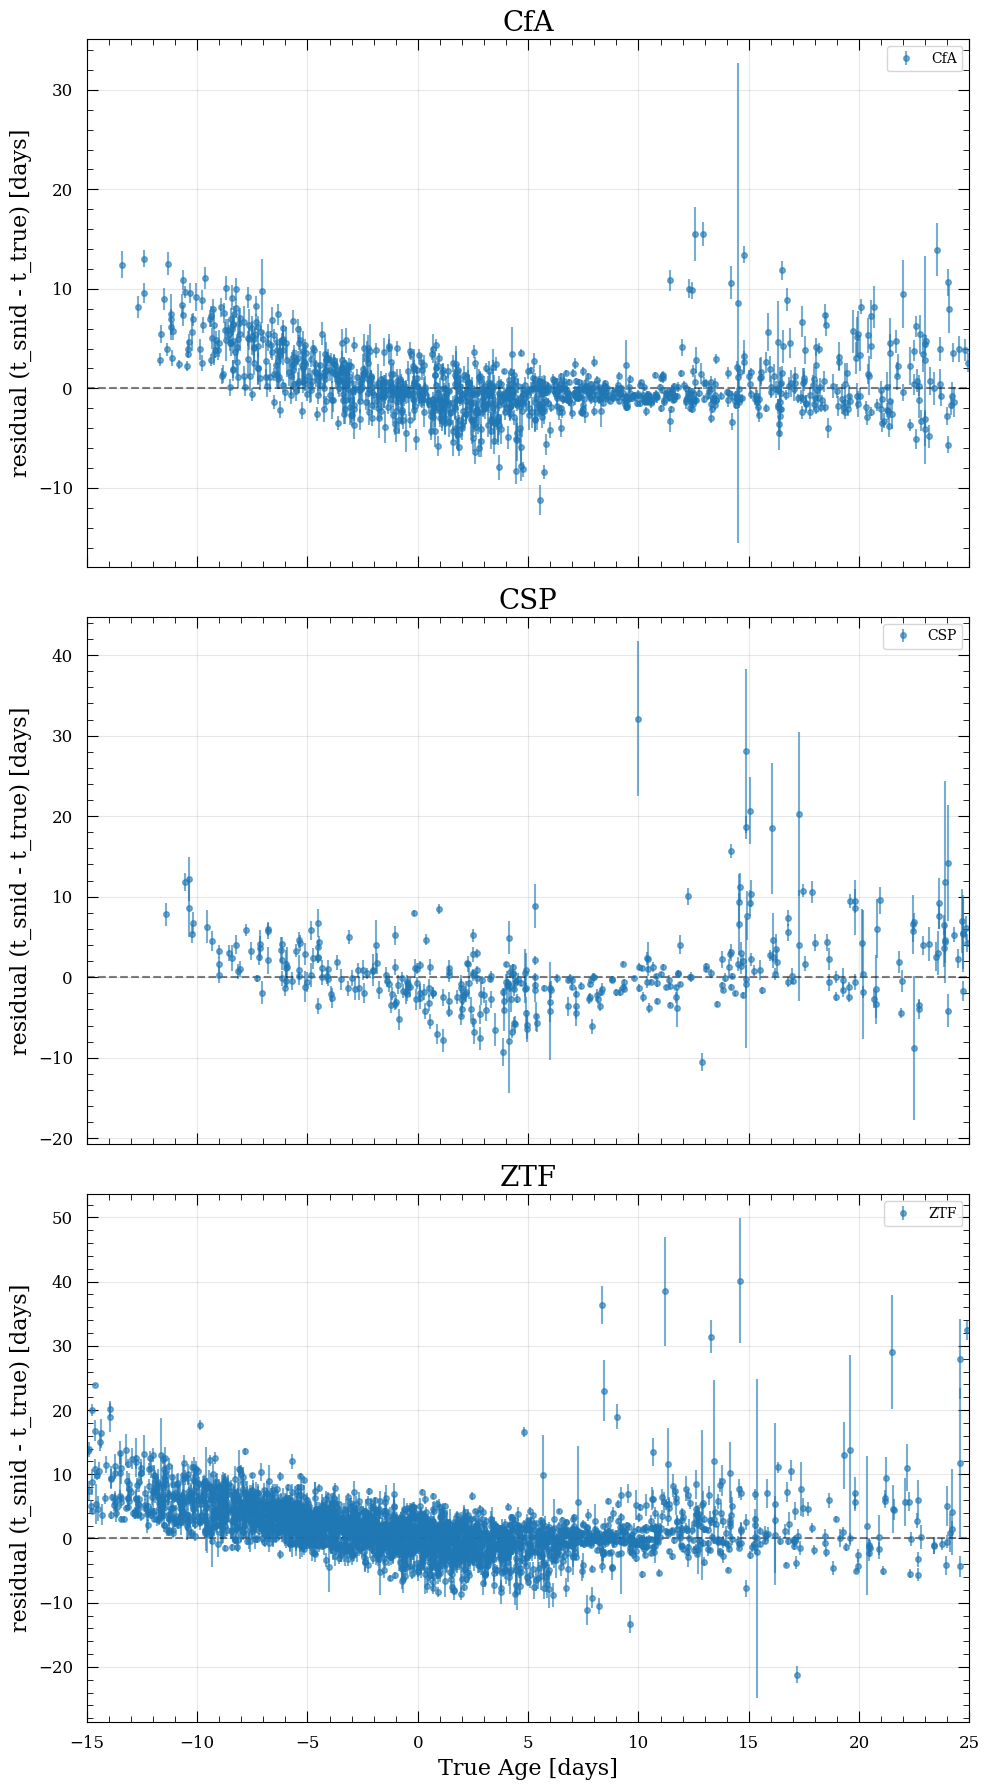

In [90]:
plot_df = combined_df[(combined_df['t_true'] >= -15) & (combined_df['t_true'] <= 25)]

fig, axes = plt.subplots(len(datasets), 1, figsize=(10, 6 * len(datasets)), sharex=True)

for ax, name in zip(axes, datasets.keys()):
    subset = plot_df[plot_df['dataset'] == name]
    ax.errorbar(
        subset['t_true'], subset['residual'],
        yerr=subset['t_err'],
        fmt='o', alpha=0.6, markersize=4, label=name
    )
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlim(-15, 25)
    ax.set_ylabel('residual (t_snid - t_true) [days]')
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('True Age [days]')
plt.tight_layout()
plt.show()

In [91]:
# Filter to requested range
plot1_df = combined_df.copy()
plot1_df = plot1_df[(plot1_df['t_true'] >= -15) & (plot1_df['t_true'] <= 25)]

# Binning and calculating metrics
bin_size = 5
bins = np.arange(-15, 26, bin_size)
plot1_df['age_bin'] = pd.cut(plot1_df['t_true'], bins=bins)

def get_metrics(group):
    return pd.Series({
        'bias': group['residual'].mean(),
        'spread': group['residual'].std(),
        'rmse': np.sqrt((group['residual']**2).mean()),
        'count': len(group),
        'mean_err': group['t_err'].mean()
    })

metrics_df = plot1_df.groupby(['dataset', 'age_bin']).apply(get_metrics).reset_index()

# Convert age_bin to midpoint for plotting
metrics_df['bin_midpoint'] = metrics_df['age_bin'].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

os.makedirs('../../output/comparison_analysis', exist_ok=True)
metrics_df.to_csv('../../output/comparison_analysis/comparison_metrics.csv', index=False)
print("Metrics saved to output/comparison_analysis/comparison_metrics.csv")

print(metrics_df.head())

Metrics saved to output/comparison_analysis/comparison_metrics.csv
  dataset     age_bin      bias    spread      rmse  count  mean_err  \
0     CSP  (-15, -10]  8.750833  2.716712  9.095467    6.0  1.891728   
1     CSP   (-10, -5]  2.209145  2.218834  3.110303   38.0  1.208575   
2     CSP     (-5, 0]  0.265670  2.698956  2.687911   56.0  1.063583   
3     CSP      (0, 5] -1.763198  3.193572  3.631691   86.0  1.111887   
4     CSP     (5, 10] -0.646250  5.573138  5.547215   44.0  1.049106   

  bin_midpoint  
0        -12.5  
1         -7.5  
2         -2.5  
3          2.5  
4          7.5  


/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_26224/179451070.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metrics_df = plot1_df.groupby(['dataset', 'age_bin']).apply(get_metrics).reset_index()
/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_26224/179451070.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_df = plot1_df.groupby(['dataset', 'age_bin']).apply(get_metrics).reset_index()


In [92]:
STYLE_FILE = '../../src/GausSN.mplstyle'
plt.style.use(STYLE_FILE)

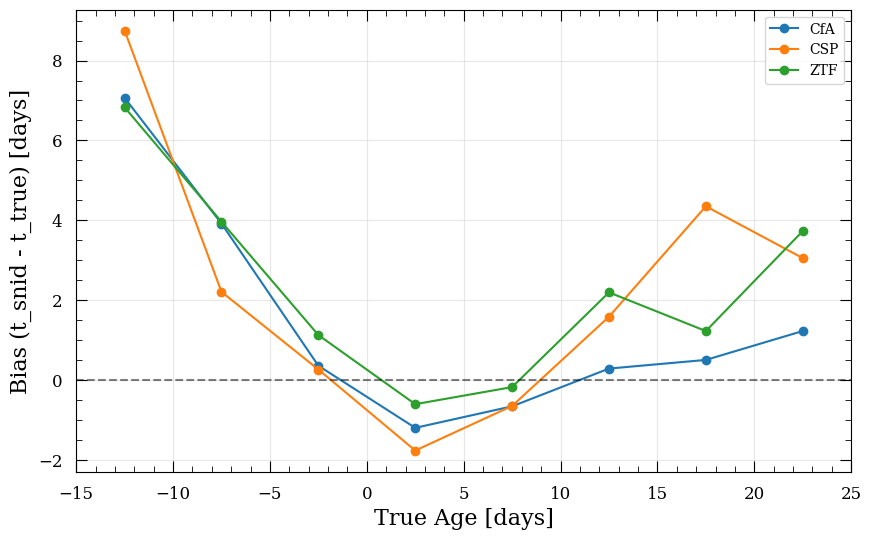

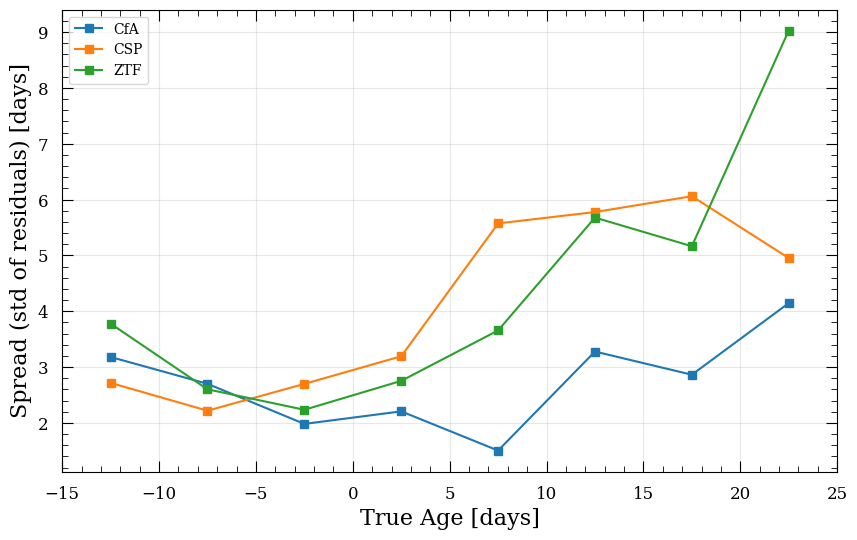

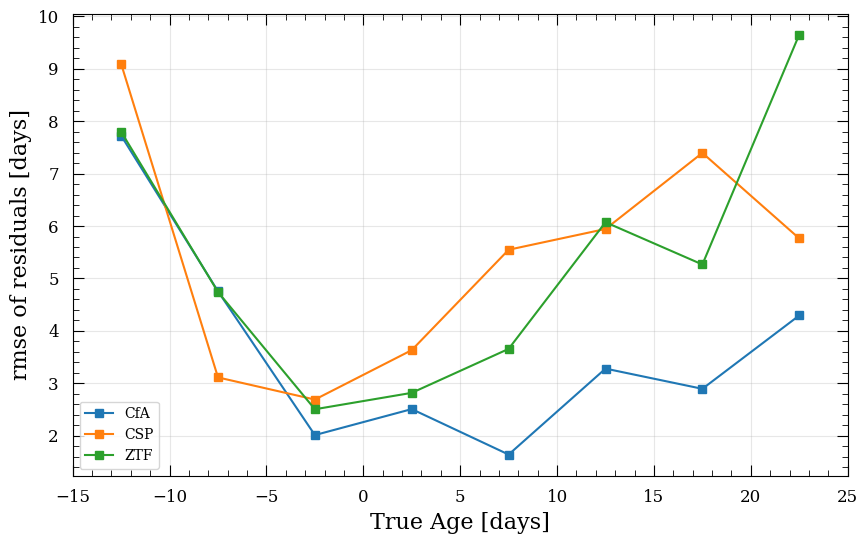

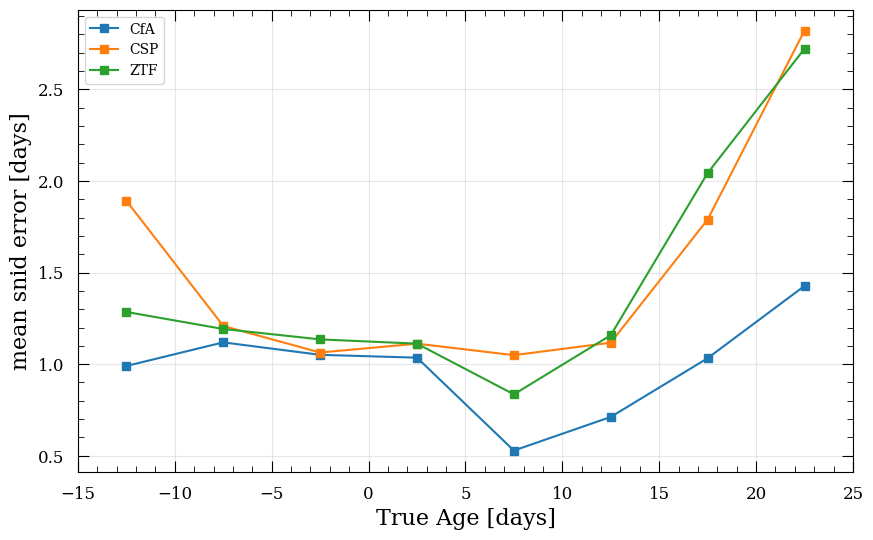

In [93]:
# Plotting Bias
plt.figure(figsize=(10, 6))
for name in datasets.keys():
    subset = metrics_df[metrics_df['dataset'] == name].dropna(subset=['bias'])
    if not subset.empty:
        plt.plot(subset['bin_midpoint'], subset['bias'], marker='o', label=name)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlim(-15, 25)
plt.xlabel('True Age [days]')
plt.ylabel('Bias (t_snid - t_true) [days]')
# plt.title('SNID Age Bias vs True Age (-15 to 25 days, 5-day bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../output/comparison_analysis/bias_comparison.png')
plt.show()

# Plotting Spread
plt.figure(figsize=(10, 6))
for name in datasets.keys():
    subset = metrics_df[metrics_df['dataset'] == name].dropna(subset=['spread'])
    if not subset.empty:
        plt.plot(subset['bin_midpoint'], subset['spread'], marker='s', label=name)

plt.xlim(-15, 25)
plt.xlabel('True Age [days]')
plt.ylabel('Spread (std of residuals) [days]')
# plt.title('SNID Age Spread vs True Age (-15 to 25 days, 5-day bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../output/comparison_analysis/spread_comparison.png')
plt.show()

# Plotting RMSE
plt.figure(figsize=(10, 6))
for name in datasets.keys():
    subset = metrics_df[metrics_df['dataset'] == name].dropna(subset=['rmse'])
    if not subset.empty:
        plt.plot(subset['bin_midpoint'], subset['rmse'], marker='s', label=name)

plt.xlim(-15, 25)
plt.xlabel('True Age [days]')
plt.ylabel('rmse of residuals [days]')
# plt.title('SNID Age Spread vs True Age (-15 to 25 days, 5-day bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../output/comparison_analysis/rmse_comparison.png')
plt.show()

# Plotting RMSE
plt.figure(figsize=(10, 6))
for name in datasets.keys():
    subset = metrics_df[metrics_df['dataset'] == name].dropna(subset=['mean_err'])
    if not subset.empty:
        plt.plot(subset['bin_midpoint'], subset['mean_err'], marker='s', label=name)

plt.xlim(-15, 25)
plt.xlabel('True Age [days]')
plt.ylabel('mean snid error [days]')
# plt.title('SNID Age Spread vs True Age (-15 to 25 days, 5-day bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../output/comparison_analysis/mean_snid_err_comparison.png')
plt.show()

In [115]:
# Filter to requested range
plot2_df= combined_df.copy()
plot2_df = plot2_df[(plot2_df['t_true'] >= -15) & (plot2_df['t_true'] <= 25)]

# Binning and calculating metrics
bin_size = 2
bins = np.arange(-15, 26, bin_size)
plot2_df['age_bin'] = pd.cut(plot2_df['t_true'], bins=bins)

def get_metrics(group):
    return pd.Series({
        'bias': group['residual'].mean(),
        'spread': group['residual'].std(),
        'rmse': np.sqrt((group['residual']**2).mean()),
        'count': len(group),
        'mean_err': group['t_err'].mean(),
        'chi2_reduced': (group['norm_residual']**2).mean(),
        'mad': group['residual'].abs().median(),
        'coverage_1sigma': (group['residual'].abs() < group['t_err']).mean(),
        'coverage_2sigma': (group['residual'].abs() < 2*group['t_err']).mean()

    })


metrics_df = plot2_df.groupby(['dataset', 'age_bin']).apply(get_metrics).reset_index()

# metrics_df = metrics_df.dropna(subset=['chi2_reduced'])
# metrics_df = metrics_df[
#     (metrics_df['chi2_reduced']<=100)
# ]

# Convert age_bin to midpoint for plotting
metrics_df['bin_midpoint'] = metrics_df['age_bin'].apply(lambda x: x.mid if pd.notnull(x) else np.nan)

# # os.makedirs('../../output/comparison_analysis', exist_ok=True)
metrics_df.to_csv('../../output/comparison_analysis/2daybin_comparison_metrics.csv', index=False)
# print("Metrics saved to output/comparison_analysis/comparison_metrics.csv")

/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_26224/958411513.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metrics_df = plot2_df.groupby(['dataset', 'age_bin']).apply(get_metrics).reset_index()
/var/folders/qn/w0hwzpl9009_4d15fgh446c80000gq/T/ipykernel_26224/958411513.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_df = plot2_df.groupby(['dataset', 'age_bin']).apply(get_metrics).reset_index()


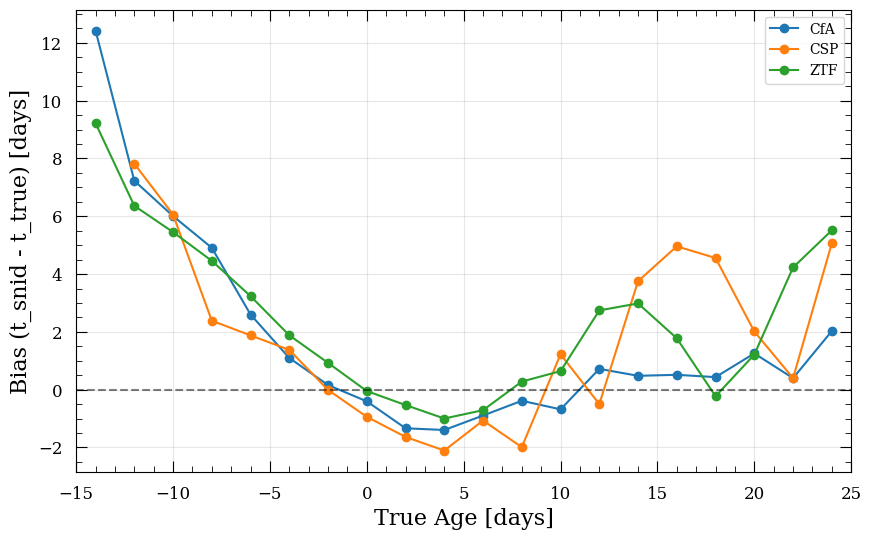

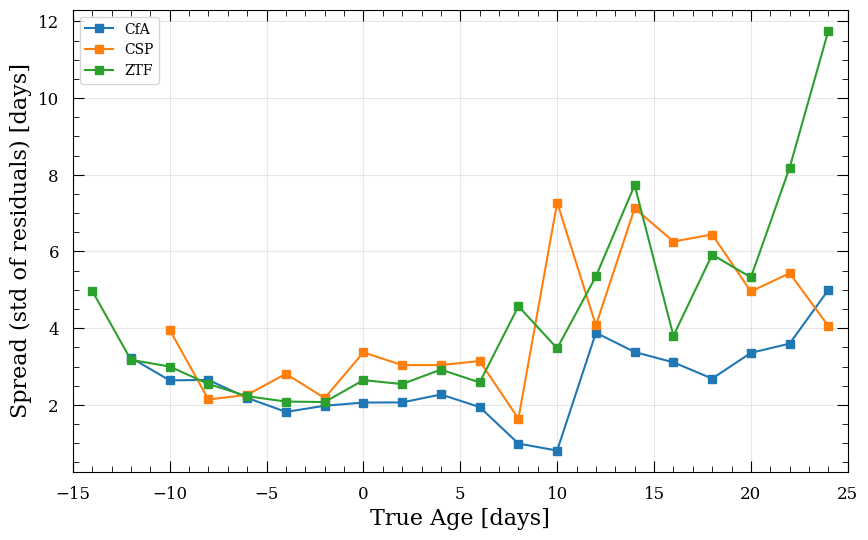

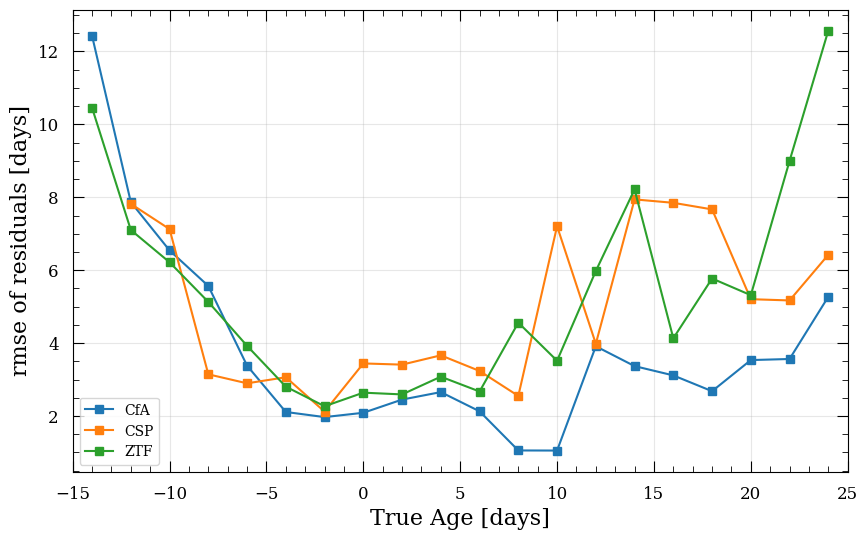

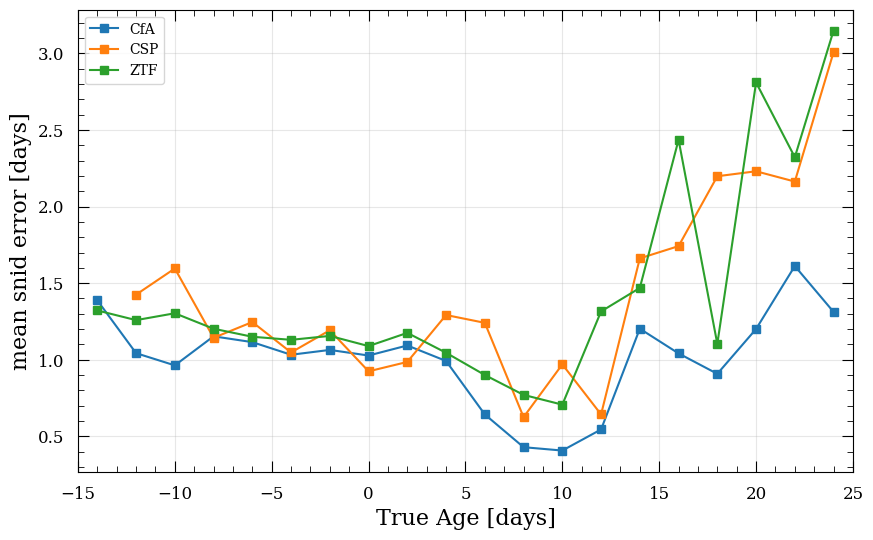

In [111]:
# Plotting Bias
plt.figure(figsize=(10, 6))
for name in datasets.keys():
    subset = metrics_df[metrics_df['dataset'] == name].dropna(subset=['bias'])
    if not subset.empty:
        plt.plot(subset['bin_midpoint'], subset['bias'], marker='o', label=name)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlim(-15, 25)
plt.xlabel('True Age [days]')
plt.ylabel('Bias (t_snid - t_true) [days]')
# plt.title('SNID Age Bias vs True Age (-15 to 25 days, 5-day bins)')
plt.legend()
plt.grid(True, alpha=0.3)
# plt.savefig('../../output/comparison_analysis/bias_comparison.png')
plt.show()

# Plotting Spread
plt.figure(figsize=(10, 6))
for name in datasets.keys():
    subset = metrics_df[metrics_df['dataset'] == name].dropna(subset=['spread'])
    if not subset.empty:
        plt.plot(subset['bin_midpoint'], subset['spread'], marker='s', label=name)

plt.xlim(-15, 25)
plt.xlabel('True Age [days]')
plt.ylabel('Spread (std of residuals) [days]')
# plt.title('SNID Age Spread vs True Age (-15 to 25 days, 5-day bins)')
plt.legend()
plt.grid(True, alpha=0.3)
# plt.savefig('../../output/comparison_analysis/spread_comparison.png')
plt.show()

# Plotting RMSE
plt.figure(figsize=(10, 6))
for name in datasets.keys():
    subset = metrics_df[metrics_df['dataset'] == name].dropna(subset=['rmse'])
    if not subset.empty:
        plt.plot(subset['bin_midpoint'], subset['rmse'], marker='s', label=name)

plt.xlim(-15, 25)
plt.xlabel('True Age [days]')
plt.ylabel('rmse of residuals [days]')
# plt.title('SNID Age Spread vs True Age (-15 to 25 days, 5-day bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../output/comparison_analysis/rmse_comparison.png')
plt.show()

# Plotting RMSE
plt.figure(figsize=(10, 6))
for name in datasets.keys():
    subset = metrics_df[metrics_df['dataset'] == name].dropna(subset=['mean_err'])
    if not subset.empty:
        plt.plot(subset['bin_midpoint'], subset['mean_err'], marker='s', label=name)

plt.xlim(-15, 25)
plt.xlabel('True Age [days]')
plt.ylabel('mean snid error [days]')
# plt.title('SNID Age Spread vs True Age (-15 to 25 days, 5-day bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../output/comparison_analysis/mean_snid_err_comparison.png')
plt.show()

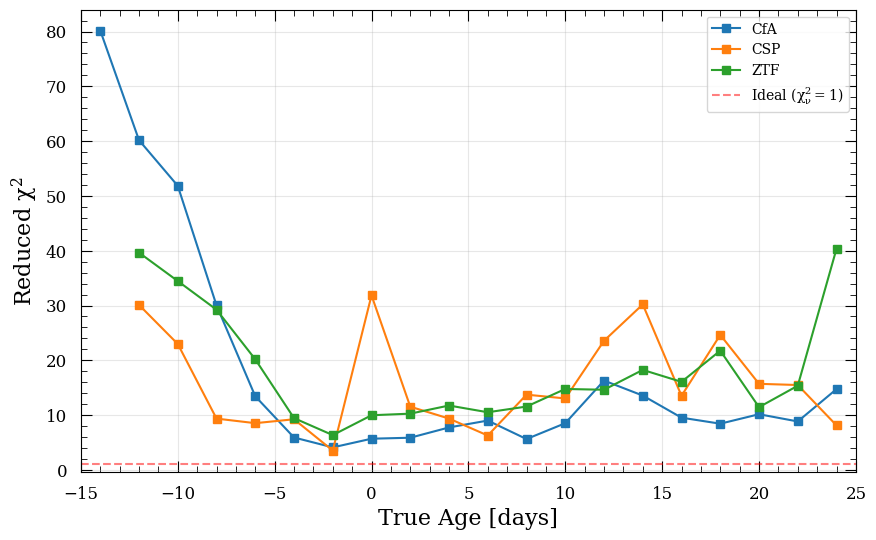

In [112]:

# Plotting Reduced Chi-Squared
plt.figure(figsize=(10, 6))
for name in datasets.keys():
    subset = metrics_df[(metrics_df['dataset'] == name) & (metrics_df['chi2_reduced'] <= 200)].dropna(subset=['chi2_reduced'])
    if not subset.empty:
        plt.plot(subset['bin_midpoint'], subset['chi2_reduced'], marker='s', label=name)

plt.axhline(1, color='red', linestyle='--', alpha=0.5, label='Ideal ($\\chi^2_\\nu=1$)')
plt.xlim(-15, 25)
plt.xlabel('True Age [days]')
plt.ylabel('Reduced $\\chi^2$')
# plt.title('SNID Age Spread vs True Age (-15 to 25 days, 5-day bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../output/comparison_analysis/chi2_reduced_comparison.png')
plt.show()

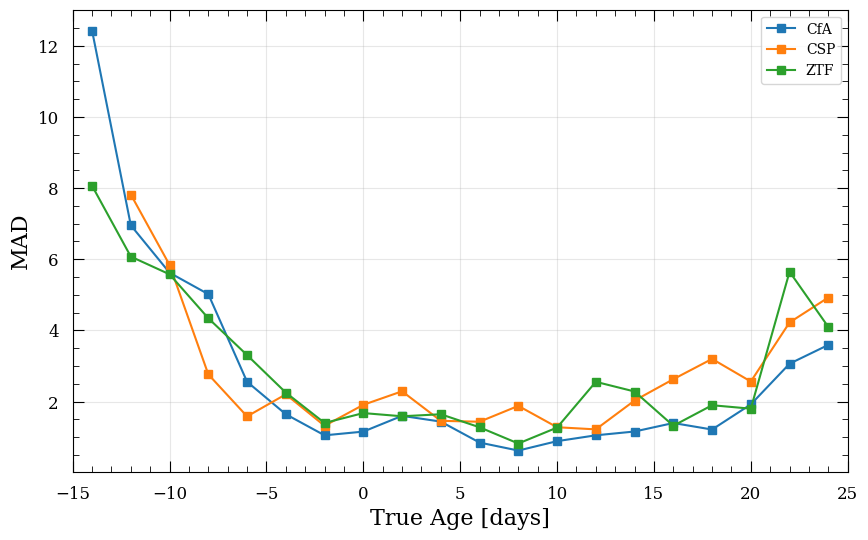

In [113]:

# Plotting Reduced MAD
plt.figure(figsize=(10, 6))
for name in datasets.keys():
    subset = metrics_df[(metrics_df['dataset'] == name)].dropna(subset=['mad'])
    if not subset.empty:
        plt.plot(subset['bin_midpoint'], subset['mad'], marker='s', label=name)

# plt.axhline(1, color='red', linestyle='--', alpha=0.5, label='Ideal ($\\chi^2_\\nu=1$)')
plt.xlim(-15, 25)
plt.xlabel('True Age [days]')
plt.ylabel('MAD')
# plt.title('SNID Age Spread vs True Age (-15 to 25 days, 5-day bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../output/comparison_analysis/mad_comparison.png')
plt.show()

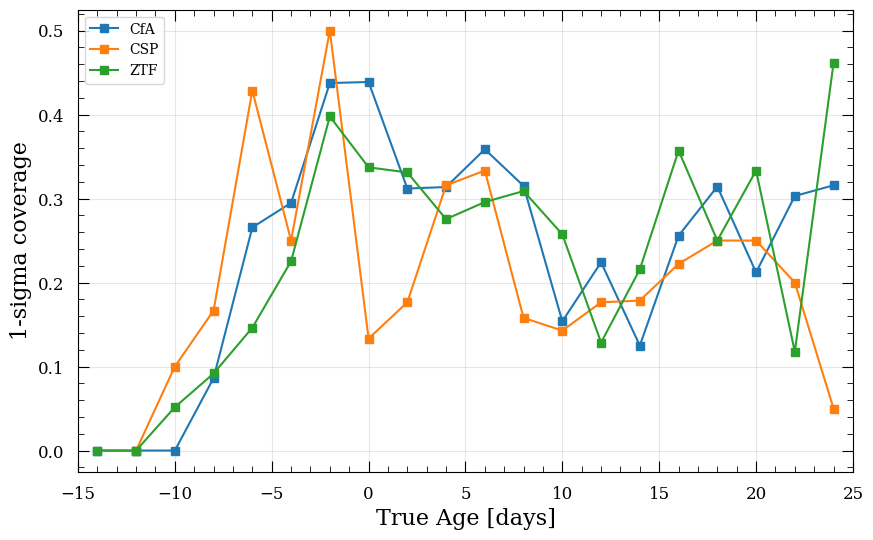

In [114]:

# Plotting 1sigma coverage
plt.figure(figsize=(10, 6))
for name in datasets.keys():
    subset = metrics_df[(metrics_df['dataset'] == name)].dropna(subset=['coverage_1sigma'])
    if not subset.empty:
        plt.plot(subset['bin_midpoint'], subset['coverage_1sigma'], marker='s', label=name)

# plt.axhline(1, color='red', linestyle='--', alpha=0.5, label='Ideal ($\\chi^2_\\nu=1$)')
plt.xlim(-15, 25)
plt.xlabel('True Age [days]')
plt.ylabel('1-sigma coverage')
# plt.title('SNID Age Spread vs True Age (-15 to 25 days, 5-day bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../output/comparison_analysis/coverage_1sigma_comparison.png')
plt.show()

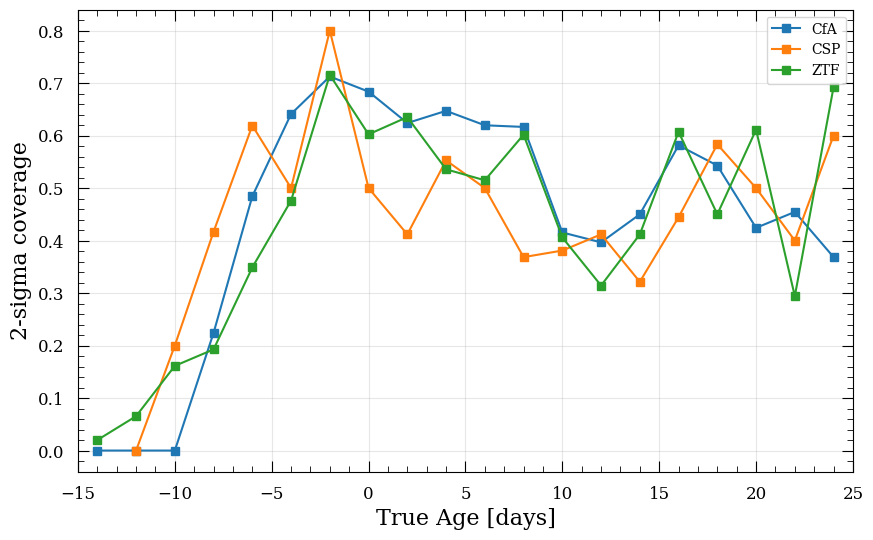

In [116]:

# Plotting 2sigma coverage
plt.figure(figsize=(10, 6))
for name in datasets.keys():
    subset = metrics_df[(metrics_df['dataset'] == name)].dropna(subset=['coverage_2sigma'])
    if not subset.empty:
        plt.plot(subset['bin_midpoint'], subset['coverage_2sigma'], marker='s', label=name)

# plt.axhline(1, color='red', linestyle='--', alpha=0.5, label='Ideal ($\\chi^2_\\nu=1$)')
plt.xlim(-15, 25)
plt.xlabel('True Age [days]')
plt.ylabel('2-sigma coverage')
# plt.title('SNID Age Spread vs True Age (-15 to 25 days, 5-day bins)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../../output/comparison_analysis/coverage_2sigma_comparison.png')
plt.show()